In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

In [ ]:
from google.colab import drive
import zipfile
import os
zip_path = '/content/drive/MyDrive/SAMPLE.zip'
extract_path = '/content/dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
if 'SAMPLE' in os.listdir(extract_path):
    final_path = os.path.join(extract_path, 'SAMPLE')
    if 'SAMPLE' in os.listdir(final_path):
        final_path = os.path.join(final_path, 'SAMPLE')
else:
    final_path = extract_path
print(f"{os.listdir(final_path)}")

['DOG', 'CAT']



  Running VGG16 - Comb 1 (Cautious)
 Tuning: LR=0.0001 | WD=0.0001 | Dropout=0.2 | Opt=Adam | Epochs=3
Epoch [1/3] -> Train Acc: 94.81% | Val Acc: 99.00%
Epoch [2/3] -> Train Acc: 98.02% | Val Acc: 99.25%
Epoch [3/3] -> Train Acc: 98.53% | Val Acc: 99.00%
99.00%

  Running VGG16 - Comb 2 (Optimal)
 Tuning: LR=0.001 | WD=1e-05 | Dropout=0.3 | Opt=Adam | Epochs=5
Epoch [1/5] -> Train Acc: 97.61% | Val Acc: 99.25%
Epoch [2/5] -> Train Acc: 98.30% | Val Acc: 98.88%
Epoch [3/5] -> Train Acc: 98.42% | Val Acc: 98.75%
Epoch [4/5] -> Train Acc: 98.70% | Val Acc: 98.62%
Epoch [5/5] -> Train Acc: 98.61% | Val Acc: 98.88%

  Running VGG16 - Comb 3 (Classic SGD)
 Tuning: LR=0.01 | WD=0.0 | Dropout=0.5 | Opt=SGD | Epochs=10
Epoch [1/10] -> Train Acc: 96.53% | Val Acc: 98.00%
Epoch [2/10] -> Train Acc: 97.30% | Val Acc: 99.38%
Epoch [3/10] -> Train Acc: 97.41% | Val Acc: 99.12%
Epoch [4/10] -> Train Acc: 97.92% | Val Acc: 98.38%
Epoch [5/10] -> Train Acc: 97.91% | Val Acc: 99.12%
Epoch [6/10] -> Tr

,Architecture,Combination,Hyperparameters Config,Training Performance,Validation Performance
0,VGG16,Comb 3 (Classic SGD),"lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Epochs=10",98.19%,99.50%
1,VGG16,Comb 1 (Cautious),"lr=0.0001, WD=0.0001, Drop=0.2, Opt=Adam, Epoc...",98.53%,99.00%
2,VGG16,Comb 2 (Optimal),"lr=0.001, WD=1e-05, Drop=0.3, Opt=Adam, Epochs=5",98.61%,98.88%


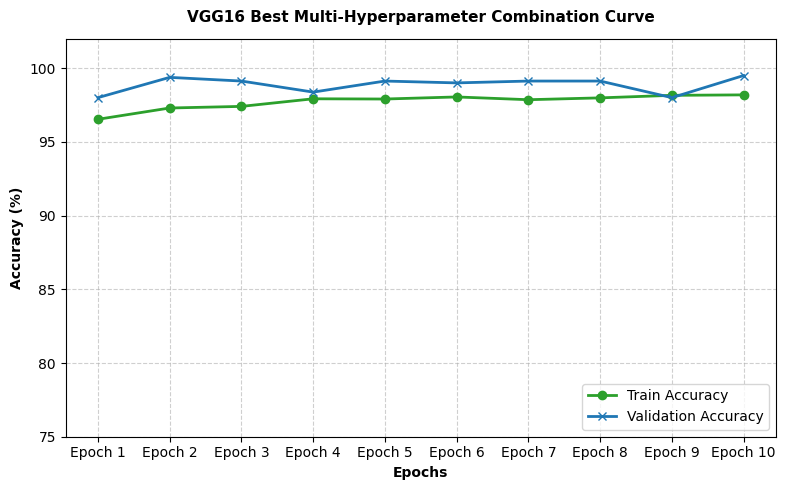

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
combinations = [
    {"name": "Comb 1 ",   "lr": 0.0001, "weight_decay": 1e-4, "dropout": 0.2, "optimizer": "Adam", "epochs": 3},
    {"name": "Comb 2 ",    "lr": 0.001,  "weight_decay": 1e-5, "dropout": 0.3, "optimizer": "Adam", "epochs": 5},
    {"name": "Comb 3 ","lr": 0.01,   "weight_decay": 0.0,  "dropout": 0.5, "optimizer": "SGD",  "epochs": 10}
]

vgg_results = []
best_vgg_val_acc = 0
best_vgg_history = None
best_vgg_epochs = 3

for comb in combinations:
    current_epochs = comb['epochs']
    print(f"\n==================================================")
    print(f"  Running VGG16 - {comb['name']}")
    print(f" Tuning: LR={comb['lr']} | WD={comb['weight_decay']} | Dropout={comb['dropout']} | Opt={comb['optimizer']} | Epochs={current_epochs}")
    print(f"==================================================")
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Dropout(p=comb['dropout']),
        nn.Linear(num_features, 2)
    )
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    if comb['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.classifier[6].parameters(), lr=comb['lr'], weight_decay=comb['weight_decay'])
    elif comb['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.classifier[6].parameters(), lr=comb['lr'], momentum=0.9, weight_decay=comb['weight_decay'])

    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(current_epochs):
        model.train()
        correct_train, total_train = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = (correct_train / total_train) * 100

        model.eval()
        correct_valid, total_valid = 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_valid += labels.size(0)
                correct_valid += (predicted == labels).sum().item()

        val_acc = (correct_valid / total_valid) * 100
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{current_epochs}] -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    vgg_results.append({
        'Architecture': 'VGG16',
        'Combination': comb['name'],
        'Hyperparameters Config': f"lr={comb['lr']}, WD={comb['weight_decay']}, Drop={comb['dropout']}, Opt={comb['optimizer']}, Epochs={current_epochs}",
        'Training Performance Raw': train_acc,
        'Validation Performance Raw': val_acc
    })

    if val_acc > best_vgg_val_acc:
        best_vgg_val_acc = val_acc
        best_vgg_history = history
        best_vgg_epochs = current_epochs
        torch.save(model.state_dict(), 'vgg16_best_model.pth')
        print(f"{val_acc:.2f}%")







df_vgg = pd.DataFrame(vgg_results)
df_vgg = df_vgg.sort_values(by='Validation Performance Raw', ascending=False).reset_index(drop=True)
df_vgg['Training Performance'] = df_vgg['Training Performance Raw'].apply(lambda x: f"{x:.2f}%")
df_vgg['Validation Performance'] = df_vgg['Validation Performance Raw'].apply(lambda x: f"{x:.2f}%")
df_vgg_final = df_vgg.drop(columns=['Training Performance Raw', 'Validation Performance Raw'])
print("\n Table 3 Dataset Component for VGG16 (Sorted: Best Model First):")
display(df_vgg_final)





plt.figure(figsize=(8, 5), dpi=100)
plt.plot(best_vgg_history['train_acc'], label='Train Accuracy', marker='o', color='#2ca02c', linewidth=2)
plt.plot(best_vgg_history['val_acc'], label='Validation Accuracy', marker='x', color='#1f77b4', linewidth=2)
plt.title('VGG16 Best Multi-Hyperparameter Combination Curve', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=10, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
plt.xticks(range(best_vgg_epochs), [f"Epoch {i+1}" for i in range(best_vgg_epochs)])
plt.ylim(75, 102)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('vgg16_multi_param_curve.png')
plt.show()


  Running MobileNetV2 - Comb 1 (Cautious)
Tuning: LR=0.0001 | WD=0.0001 | Dropout=0.2 | Opt=Adam | Epochs=3
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 156MB/s]


Epoch [1/3] -> Train Acc: 85.33% | Val Acc: 94.50%
Epoch [2/3] -> Train Acc: 94.72% | Val Acc: 95.62%
Epoch [3/3] -> Train Acc: 95.31% | Val Acc: 96.12%
96.12%

  Running MobileNetV2 - Comb 2 (Optimal)
Tuning: LR=0.001 | WD=1e-05 | Dropout=0.3 | Opt=Adam | Epochs=5
Epoch [1/5] -> Train Acc: 92.38% | Val Acc: 96.25%
Epoch [2/5] -> Train Acc: 95.67% | Val Acc: 96.75%
Epoch [3/5] -> Train Acc: 96.03% | Val Acc: 97.50%
Epoch [4/5] -> Train Acc: 96.34% | Val Acc: 97.62%
Epoch [5/5] -> Train Acc: 96.27% | Val Acc: 97.50%
97.50%

  Running MobileNetV2 - Comb 3 (Classic SGD)
Tuning: LR=0.01 | WD=0.0 | Dropout=0.5 | Opt=SGD | Epochs=10
Epoch [1/10] -> Train Acc: 92.50% | Val Acc: 97.25%
Epoch [2/10] -> Train Acc: 94.56% | Val Acc: 97.75%
Epoch [3/10] -> Train Acc: 94.67% | Val Acc: 97.25%
Epoch [4/10] -> Train Acc: 95.03% | Val Acc: 95.00%
Epoch [5/10] -> Train Acc: 93.73% | Val Acc: 95.62%
Epoch [6/10] -> Train Acc: 94.58% | Val Acc: 97.00%
Epoch [7/10] -> Train Acc: 94.73% | Val Acc: 96.62%
E

,Architecture,Combination,Hyperparameters Config,Val Precision,Val Recall,Val F1-Score,Training Time,Training Performance,Validation Performance
0,MobileNetV2,Comb 2 (Optimal),"lr=0.001, WD=1e-05, Drop=0.3, Opt=Adam, Epochs=5",96.20%,98.70%,97.44%,180.91 Sec,96.27%,97.50%
1,MobileNetV2,Comb 3 (Classic SGD),"lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Epochs=10",95.95%,98.44%,97.18%,362.07 Sec,93.66%,97.25%
2,MobileNetV2,Comb 1 (Cautious),"lr=0.0001, WD=0.0001, Drop=0.2, Opt=Adam, Epoc...",96.09%,95.84%,95.97%,108.41 Sec,95.31%,96.12%


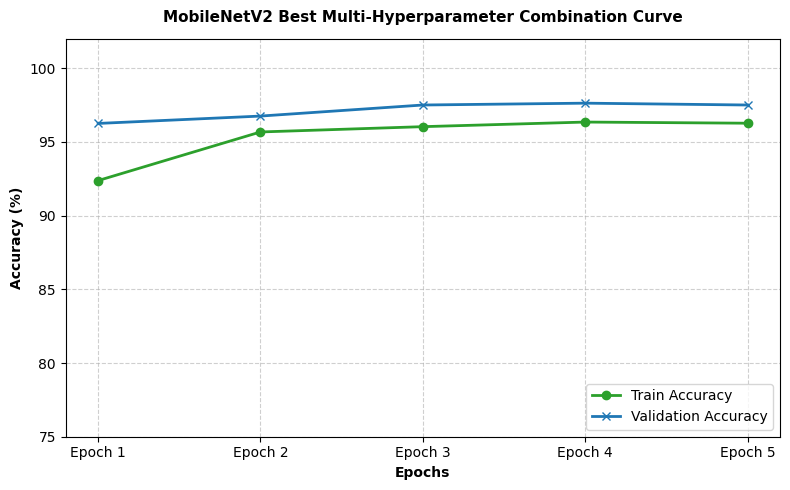

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import precision_score, recall_score, f1_score

try:
    path_to_use = final_path
except NameError:
    path_to_use = "./data"

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
full_dataset = ImageFolder(root=path_to_use, transform=data_transforms)
total_images = len(full_dataset)
train_size = int(0.8 * total_images)
valid_size = int(0.1 * total_images)
test_size = total_images - train_size - valid_size
torch.manual_seed(42)
train_data, valid_data, test_data = random_split(full_dataset, [train_size, valid_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

combinations = [
    {"name": "Comb 1 (Cautious)",   "lr": 0.0001, "weight_decay": 1e-4, "dropout": 0.2, "optimizer": "Adam", "epochs": 3},
    {"name": "Comb 2 (Optimal)",    "lr": 0.001,  "weight_decay": 1e-5, "dropout": 0.3, "optimizer": "Adam", "epochs": 5},
    {"name": "Comb 3 (Classic SGD)","lr": 0.01,   "weight_decay": 0.0,  "dropout": 0.5, "optimizer": "SGD",  "epochs": 10}
]

mobilenet_results = []
best_mobilenet_val_acc = 0
best_mobilenet_history = None
best_mobilenet_epochs = 3

for comb in combinations:
    current_epochs = comb['epochs']
    print(f"\n==================================================")
    print(f"  Running MobileNetV2 - {comb['name']}")
    print(f"Tuning: LR={comb['lr']} | WD={comb['weight_decay']} | Dropout={comb['dropout']} | Opt={comb['optimizer']} | Epochs={current_epochs}")
    print(f"==================================================")

    start_train_time = time.time()
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=comb['dropout']),
        nn.Linear(num_features, 2)
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    if comb['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.classifier.parameters(), lr=comb['lr'], weight_decay=comb['weight_decay'])
    elif comb['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.classifier.parameters(), lr=comb['lr'], momentum=0.9, weight_decay=comb['weight_decay'])

    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(current_epochs):
        model.train()
        correct_train, total_train = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = (correct_train / total_train) * 100

        model.eval()
        correct_valid, total_valid = 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_valid += labels.size(0)
                correct_valid += (predicted == labels).sum().item()

        val_acc = (correct_valid / total_valid) * 100
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{current_epochs}] -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    end_train_time = time.time()
    elapsed_training_time = end_train_time - start_train_time

    all_val_preds = []
    all_val_labels = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    prec = precision_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100
    rec = recall_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100
    f1 = f1_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100

    mobilenet_results.append({
        'Architecture': 'MobileNetV2',
        'Combination': comb['name'],
        'Hyperparameters Config': f"lr={comb['lr']}, WD={comb['weight_decay']}, Drop={comb['dropout']}, Opt={comb['optimizer']}, Epochs={current_epochs}",
        'Training Performance Raw': train_acc,
        'Validation Performance Raw': val_acc,
        'Val Precision': f"{prec:.2f}%",
        'Val Recall': f"{rec:.2f}%",
        'Val F1-Score': f"{f1:.2f}%",
        'Training Time': f"{elapsed_training_time:.2f} Sec"
    })

    if val_acc > best_mobilenet_val_acc:
        best_mobilenet_val_acc = val_acc
        best_mobilenet_history = history
        best_mobilenet_epochs = current_epochs
        torch.save(model.state_dict(), 'mobilenet_best_model.pth')
        print(f"{val_acc:.2f}%")

df_mobilenet = pd.DataFrame(mobilenet_results)
df_mobilenet = df_mobilenet.sort_values(by='Validation Performance Raw', ascending=False).reset_index(drop=True)
df_mobilenet['Training Performance'] = df_mobilenet['Training Performance Raw'].apply(lambda x: f"{x:.2f}%")
df_mobilenet['Validation Performance'] = df_mobilenet['Validation Performance Raw'].apply(lambda x: f"{x:.2f}%")
df_mobilenet_final = df_mobilenet.drop(columns=['Training Performance Raw', 'Validation Performance Raw'])
print("\n Grand Summary Table for MobileNetV2 (Sorted: Best Model First):")
display(df_mobilenet_final)



plt.figure(figsize=(8, 5), dpi=100)
plt.plot(best_mobilenet_history['train_acc'], label='Train Accuracy', marker='o', color='#2ca02c', linewidth=2)
plt.plot(best_mobilenet_history['val_acc'], label='Validation Accuracy', marker='x', color='#1f77b4', linewidth=2)
plt.title('MobileNetV2 Best Multi-Hyperparameter Combination Curve', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=10, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
plt.xticks(range(best_mobilenet_epochs), [f"Epoch {i+1}" for i in range(best_mobilenet_epochs)])
plt.ylim(75, 102)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('mobilenetv2_multi_param_curve.png')
plt.show()


  Running ResNet50 - Comb 1 (Cautious)
 Tuning: LR=0.0001 | WD=0.0001 | Dropout=0.2 | Opt=Adam | Epochs=3
Epoch [1/3] -> Train Acc: 88.75% | Val Acc: 96.25%
Epoch [2/3] -> Train Acc: 95.75% | Val Acc: 97.12%
Epoch [3/3] -> Train Acc: 96.58% | Val Acc: 97.88%
 97.88%

  Running ResNet50 - Comb 2 (Optimal)
 Tuning: LR=0.001 | WD=1e-05 | Dropout=0.3 | Opt=Adam | Epochs=5
Epoch [1/5] -> Train Acc: 94.95% | Val Acc: 97.62%
Epoch [2/5] -> Train Acc: 96.83% | Val Acc: 98.12%
Epoch [3/5] -> Train Acc: 97.42% | Val Acc: 97.62%
Epoch [4/5] -> Train Acc: 96.92% | Val Acc: 98.50%
Epoch [5/5] -> Train Acc: 97.42% | Val Acc: 98.75%
 98.75%

  Running ResNet50 - Comb 3 (Classic SGD)
 Tuning: LR=0.01 | WD=0.0 | Dropout=0.5 | Opt=SGD | Epochs=10
Epoch [1/10] -> Train Acc: 94.70% | Val Acc: 98.12%
Epoch [2/10] -> Train Acc: 95.42% | Val Acc: 97.38%
Epoch [3/10] -> Train Acc: 95.83% | Val Acc: 97.75%
Epoch [4/10] -> Train Acc: 96.09% | Val Acc: 98.38%
Epoch [5/10] -> Train Acc: 96.34% | Val Acc: 98.25%


,Architecture,Combination,Hyperparameters Config,Val Precision,Val Recall,Val F1-Score,Training Time,Training Performance,Validation Performance
0,ResNet50,Comb 2 (Optimal),"lr=0.001, WD=1e-05, Drop=0.3, Opt=Adam, Epochs=5",98.70%,98.70%,98.70%,238.21 Sec,97.42%,98.75%
1,ResNet50,Comb 3 (Classic SGD),"lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Epochs=10",98.96%,98.44%,98.70%,486.96 Sec,96.23%,98.75%
2,ResNet50,Comb 1 (Cautious),"lr=0.0001, WD=0.0001, Drop=0.2, Opt=Adam, Epoc...",97.18%,98.44%,97.81%,142.11 Sec,96.58%,97.88%


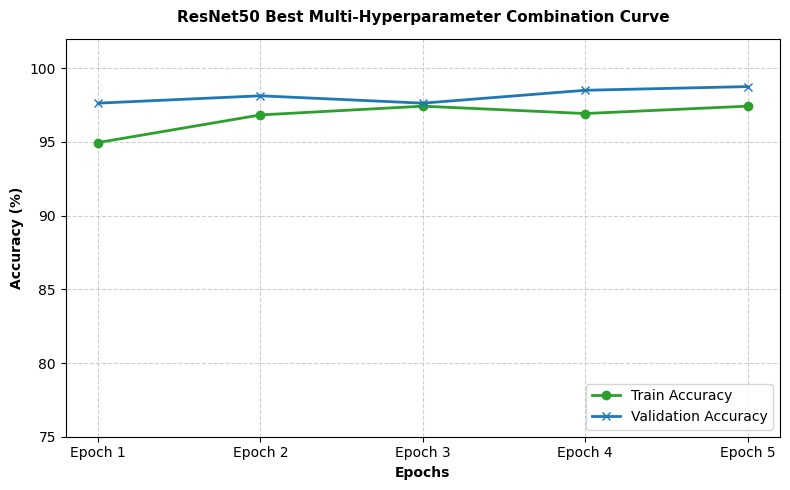

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import precision_score, recall_score, f1_score

try:
    path_to_use = final_path
except NameError:
    path_to_use = "./data"
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=path_to_use, transform=data_transforms)
total_images = len(full_dataset)

train_size = int(0.8 * total_images)
valid_size = int(0.1 * total_images)
test_size = total_images - train_size - valid_size

torch.manual_seed(42)
train_data, valid_data, test_data = random_split(full_dataset, [train_size, valid_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

combinations = [
    {"name": "Comb 1 (Cautious)",   "lr": 0.0001, "weight_decay": 1e-4, "dropout": 0.2, "optimizer": "Adam", "epochs": 3},
    {"name": "Comb 2 (Optimal)",    "lr": 0.001,  "weight_decay": 1e-5, "dropout": 0.3, "optimizer": "Adam", "epochs": 5},
    {"name": "Comb 3 (Classic SGD)","lr": 0.01,   "weight_decay": 0.0,  "dropout": 0.5, "optimizer": "SGD",  "epochs": 10}
]

resnet_results = []
best_resnet_val_acc = 0
best_resnet_history = None
best_resnet_epochs = 3

for comb in combinations:
    current_epochs = comb['epochs']

    print(f"\n==================================================")
    print(f"  Running ResNet50 - {comb['name']}")
    print(f" Tuning: LR={comb['lr']} | WD={comb['weight_decay']} | Dropout={comb['dropout']} | Opt={comb['optimizer']} | Epochs={current_epochs}")
    print(f"==================================================")

    start_train_time = time.time()

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=comb['dropout']),
        nn.Linear(num_features, 2)
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    if comb['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.fc.parameters(), lr=comb['lr'], weight_decay=comb['weight_decay'])
    elif comb['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.fc.parameters(), lr=comb['lr'], momentum=0.9, weight_decay=comb['weight_decay'])

    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(current_epochs):
        model.train()
        correct_train, total_train = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = (correct_train / total_train) * 100

        model.eval()
        correct_valid, total_valid = 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_valid += labels.size(0)
                correct_valid += (predicted == labels).sum().item()

        val_acc = (correct_valid / total_valid) * 100
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{current_epochs}] -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    end_train_time = time.time()
    elapsed_training_time = end_train_time - start_train_time

    all_val_preds = []
    all_val_labels = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    prec = precision_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100
    rec = recall_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100
    f1 = f1_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100

    resnet_results.append({
        'Architecture': 'ResNet50',
        'Combination': comb['name'],
        'Hyperparameters Config': f"lr={comb['lr']}, WD={comb['weight_decay']}, Drop={comb['dropout']}, Opt={comb['optimizer']}, Epochs={current_epochs}",
        'Training Performance Raw': train_acc,
        'Validation Performance Raw': val_acc,
        'Val Precision': f"{prec:.2f}%",
        'Val Recall': f"{rec:.2f}%",
        'Val F1-Score': f"{f1:.2f}%",
        'Training Time': f"{elapsed_training_time:.2f} Sec"
    })

    if val_acc > best_resnet_val_acc:
        best_resnet_val_acc = val_acc
        best_resnet_history = history
        best_resnet_epochs = current_epochs
        torch.save(model.state_dict(), 'resnet50_best_model.pth')
        print(f" {val_acc:.2f}%")

df_resnet = pd.DataFrame(resnet_results)
df_resnet = df_resnet.sort_values(by='Validation Performance Raw', ascending=False).reset_index(drop=True)

df_resnet['Training Performance'] = df_resnet['Training Performance Raw'].apply(lambda x: f"{x:.2f}%")
df_resnet['Validation Performance'] = df_resnet['Validation Performance Raw'].apply(lambda x: f"{x:.2f}%")

df_resnet_final = df_resnet.drop(columns=['Training Performance Raw', 'Validation Performance Raw'])

print("\nGrand Summary Table for ResNet50 (Sorted: Best Model First):")
display(df_resnet_final)



plt.figure(figsize=(8, 5), dpi=100)
plt.plot(best_resnet_history['train_acc'], label='Train Accuracy', marker='o', color='#2ca02c', linewidth=2)
plt.plot(best_resnet_history['val_acc'], label='Validation Accuracy', marker='x', color='#1f77b4', linewidth=2)
plt.title('ResNet50 Best Multi-Hyperparameter Combination Curve', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=10, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
plt.xticks(range(best_resnet_epochs), [f"Epoch {i+1}" for i in range(best_resnet_epochs)])
plt.ylim(75, 102)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('resnet50_multi_param_curve.png')
plt.show()


  Running InceptionV3 - Comb 1 (Cautious)
 Tuning: LR=0.0001 | WD=0.0001 | Dropout=0.2 | Opt=Adam | Epochs=3
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 172MB/s]


Epoch [1/3] -> Train Acc: 81.38% | Val Acc: 96.50%
Epoch [2/3] -> Train Acc: 92.80% | Val Acc: 96.88%
Epoch [3/3] -> Train Acc: 93.95% | Val Acc: 96.75%
 96.75%

  Running InceptionV3 - Comb 2 (Optimal)
 Tuning: LR=0.001 | WD=1e-05 | Dropout=0.3 | Opt=Adam | Epochs=5
Epoch [1/5] -> Train Acc: 90.83% | Val Acc: 98.38%
Epoch [2/5] -> Train Acc: 94.61% | Val Acc: 97.88%
Epoch [3/5] -> Train Acc: 94.98% | Val Acc: 98.00%
Epoch [4/5] -> Train Acc: 95.36% | Val Acc: 98.38%
Epoch [5/5] -> Train Acc: 94.48% | Val Acc: 98.38%
 98.38%

  Running InceptionV3 - Comb 3 (Classic SGD)
 Tuning: LR=0.01 | WD=0.0 | Dropout=0.5 | Opt=SGD | Epochs=10
Epoch [1/10] -> Train Acc: 89.02% | Val Acc: 98.38%
Epoch [2/10] -> Train Acc: 92.34% | Val Acc: 98.00%
Epoch [3/10] -> Train Acc: 91.69% | Val Acc: 97.88%
Epoch [4/10] -> Train Acc: 92.89% | Val Acc: 97.88%
Epoch [5/10] -> Train Acc: 92.75% | Val Acc: 97.88%
Epoch [6/10] -> Train Acc: 92.77% | Val Acc: 98.38%
Epoch [7/10] -> Train Acc: 92.77% | Val Acc: 97.7

,Architecture,Combination,Hyperparameters Config,Val Precision,Val Recall,Val F1-Score,Training Time,Training Performance,Validation Performance
0,InceptionV3,Comb 3 (Classic SGD),"lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Epochs=10",98.69%,98.18%,98.44%,769.39 Sec,93.06%,98.50%
1,InceptionV3,Comb 2 (Optimal),"lr=0.001, WD=1e-05, Drop=0.3, Opt=Adam, Epochs=5",98.95%,97.66%,98.30%,357.11 Sec,94.48%,98.38%
2,InceptionV3,Comb 1 (Cautious),"lr=0.0001, WD=0.0001, Drop=0.2, Opt=Adam, Epoc...",94.76%,98.70%,96.69%,225.97 Sec,93.95%,96.75%


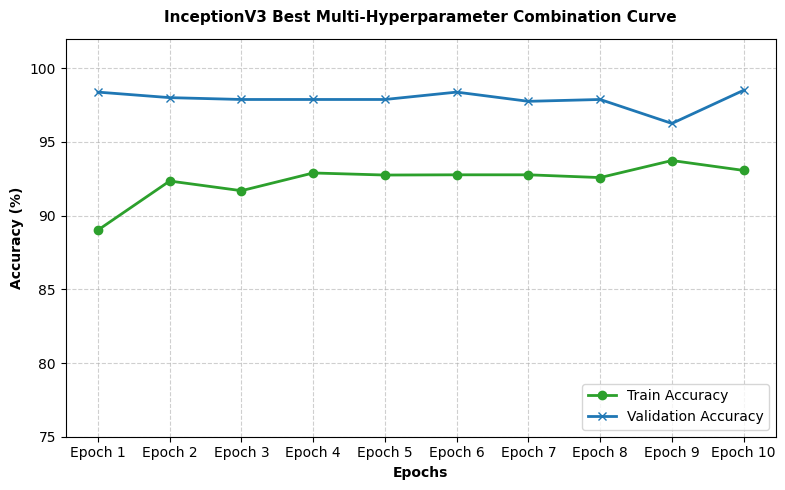

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import precision_score, recall_score, f1_score

try:
    path_to_use = final_path
except NameError:
    path_to_use = "./data"

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=path_to_use, transform=data_transforms)
total_images = len(full_dataset)

train_size = int(0.8 * total_images)
valid_size = int(0.1 * total_images)
test_size = total_images - train_size - valid_size

torch.manual_seed(42)
train_data, valid_data, test_data = random_split(full_dataset, [train_size, valid_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

combinations = [
    {"name": "Comb 1 (Cautious)",   "lr": 0.0001, "weight_decay": 1e-4, "dropout": 0.2, "optimizer": "Adam", "epochs": 3},
    {"name": "Comb 2 (Optimal)",    "lr": 0.001,  "weight_decay": 1e-5, "dropout": 0.3, "optimizer": "Adam", "epochs": 5},
    {"name": "Comb 3 (Classic SGD)","lr": 0.01,   "weight_decay": 0.0,  "dropout": 0.5, "optimizer": "SGD",  "epochs": 10}
]

inception_results = []
best_inception_val_acc = 0
best_inception_history = None
best_inception_epochs = 3

for comb in combinations:
    current_epochs = comb['epochs']

    print(f"\n==================================================")
    print(f"  Running InceptionV3 - {comb['name']}")
    print(f" Tuning: LR={comb['lr']} | WD={comb['weight_decay']} | Dropout={comb['dropout']} | Opt={comb['optimizer']} | Epochs={current_epochs}")
    print(f"==================================================")

    start_train_time = time.time()

    model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=comb['dropout']),
        nn.Linear(num_features, 2)
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    if comb['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.fc.parameters(), lr=comb['lr'], weight_decay=comb['weight_decay'])
    elif comb['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.fc.parameters(), lr=comb['lr'], momentum=0.9, weight_decay=comb['weight_decay'])

    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(current_epochs):
        model.train()
        correct_train, total_train = 0, 0
        for images, labels in train_loader:
            images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs, aux_outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = (correct_train / total_train) * 100

        model.eval()
        correct_valid, total_valid = 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_valid += labels.size(0)
                correct_valid += (predicted == labels).sum().item()

        val_acc = (correct_valid / total_valid) * 100
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{current_epochs}] -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    end_train_time = time.time()
    elapsed_training_time = end_train_time - start_train_time

    all_val_preds = []
    all_val_labels = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    prec = precision_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100
    rec = recall_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100
    f1 = f1_score(all_val_labels, all_val_preds, average='binary', zero_division=0) * 100

    inception_results.append({
        'Architecture': 'InceptionV3',
        'Combination': comb['name'],
        'Hyperparameters Config': f"lr={comb['lr']}, WD={comb['weight_decay']}, Drop={comb['dropout']}, Opt={comb['optimizer']}, Epochs={current_epochs}",
        'Training Performance Raw': train_acc,
        'Validation Performance Raw': val_acc,
        'Val Precision': f"{prec:.2f}%",
        'Val Recall': f"{rec:.2f}%",
        'Val F1-Score': f"{f1:.2f}%",
        'Training Time': f"{elapsed_training_time:.2f} Sec"
    })

    if val_acc > best_inception_val_acc:
        best_inception_val_acc = val_acc
        best_inception_history = history
        best_inception_epochs = current_epochs
        torch.save(model.state_dict(), 'inception_best_model.pth')
        print(f" {val_acc:.2f}%")

df_inception = pd.DataFrame(inception_results)
df_inception = df_inception.sort_values(by='Validation Performance Raw', ascending=False).reset_index(drop=True)

df_inception['Training Performance'] = df_inception['Training Performance Raw'].apply(lambda x: f"{x:.2f}%")
df_inception['Validation Performance'] = df_inception['Validation Performance Raw'].apply(lambda x: f"{x:.2f}%")

df_inception_final = df_inception.drop(columns=['Training Performance Raw', 'Validation Performance Raw'])

print("\n Grand Summary Table for InceptionV3 (Sorted: Best Model First):")
display(df_inception_final)

plt.figure(figsize=(8, 5), dpi=100)
plt.plot(best_inception_history['train_acc'], label='Train Accuracy', marker='o', color='#2ca02c', linewidth=2)
plt.plot(best_inception_history['val_acc'], label='Validation Accuracy', marker='x', color='#1f77b4', linewidth=2)
plt.title('InceptionV3 Best Multi-Hyperparameter Combination Curve', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=10, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
plt.xticks(range(best_inception_epochs), [f"Epoch {i+1}" for i in range(best_inception_epochs)])
plt.ylim(75, 102)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('inceptionv3_multi_param_curve.png')
plt.show()

 Loading saved best models weights on device: cuda
 Evaluating VGG16 using saved weights file: 'vgg16_best_model.pth'...
 Evaluating MobileNetV2 using saved weights file: 'mobilenet_best_model.pth'...
 Evaluating ResNet50 using saved weights file: 'resnet50_best_model.pth'...
 Evaluating InceptionV3 using saved weights file: 'inception_best_model.pth'...

 Table 4 Component (Dynamically Calculated Cross Test Set):


,Architecture,Best Hyperparameters Config,Accuracy,Precision,Recall,F1-Score
0,VGG16,"Comb 3: lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Ep=10",98.75%,98.29%,99.26%,98.77%
1,MobileNetV2,"Comb 2: lr=0.001, WD=1e-5, Drop=0.3, Opt=Adam,...",98.62%,98.05%,99.26%,98.65%
2,ResNet50,"Comb 2: lr=0.001, WD=1e-5, Drop=0.3, Opt=Adam,...",99.00%,99.01%,99.01%,99.01%
3,InceptionV3,"Comb 3: lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Ep=10",85.25%,91.86%,77.83%,84.27%


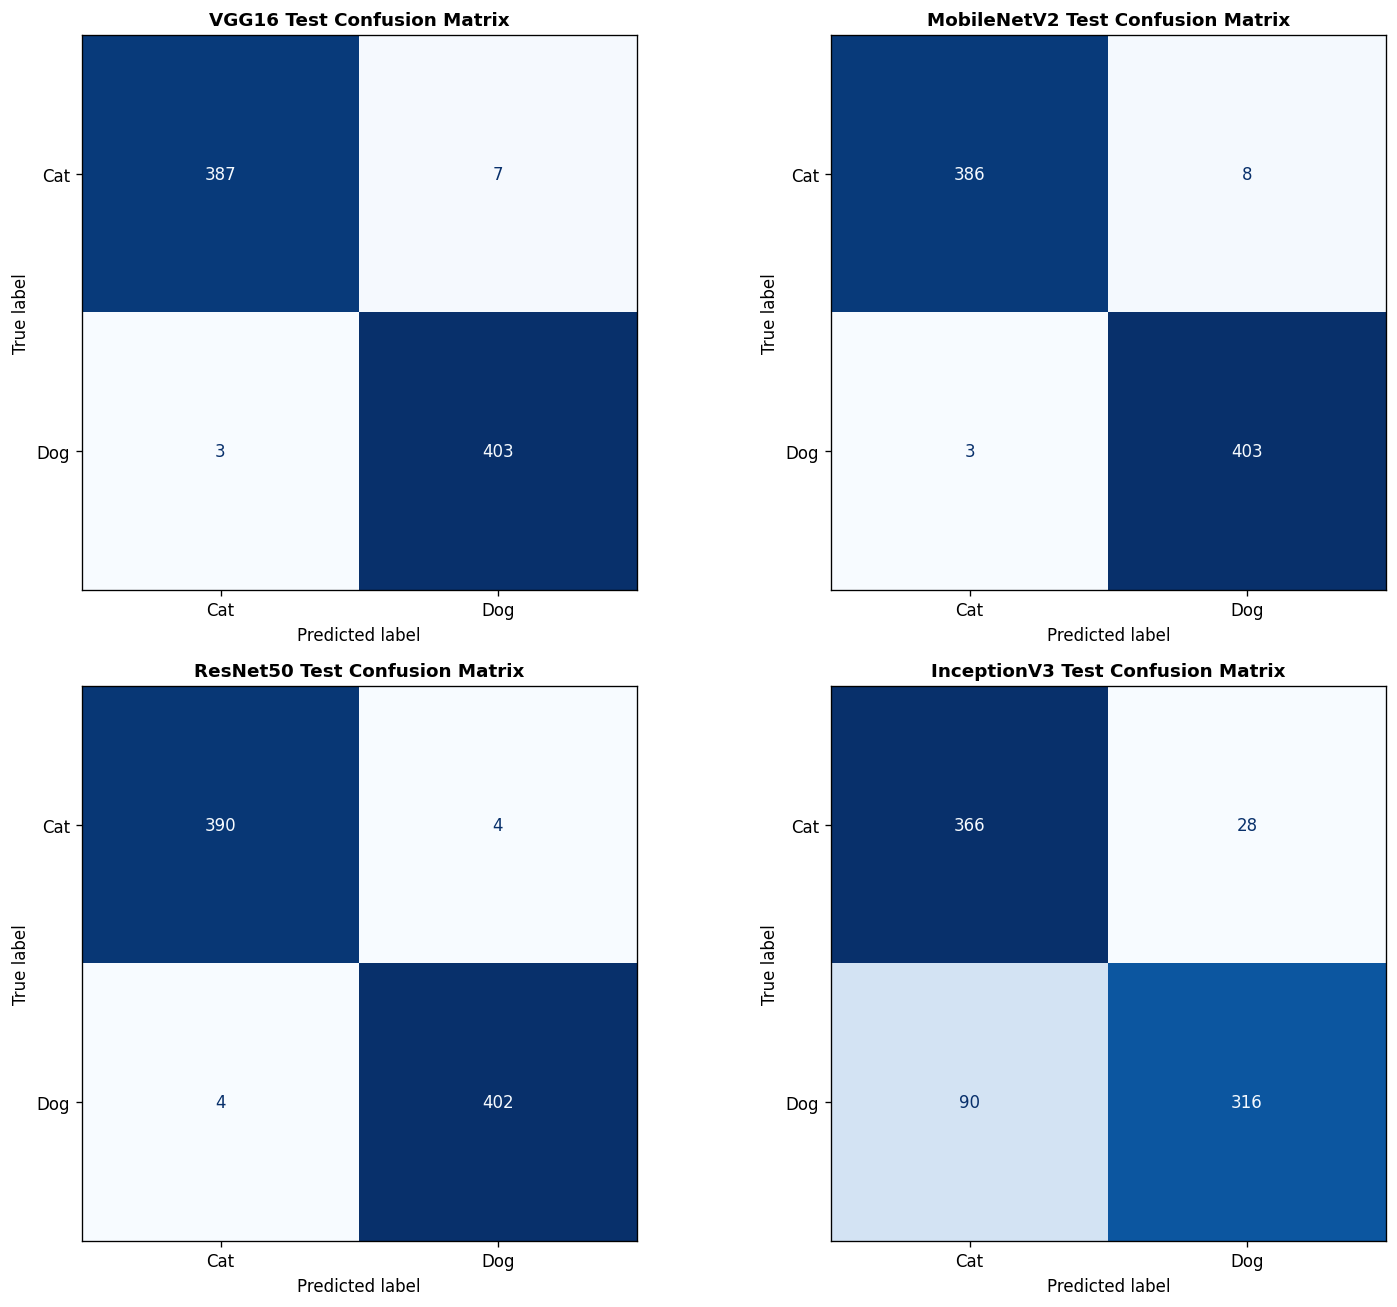

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Loading saved best models weights on device: {device}")

best_models_spec = {
    'VGG16': {
        'init_fn': lambda: models.vgg16(),
        'modify_fn': lambda m: setattr(m, 'classifier', nn.Sequential(*list(m.classifier.children())[:-1], nn.Sequential(nn.Dropout(p=0.5), nn.Linear(4096, 2)))),
        'weight_path': 'vgg16_best_model.pth', 'size': 224,
        'config': 'Comb 3: lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Ep=10'
    },
    'MobileNetV2': {
        'init_fn': lambda: models.mobilenet_v2(),
        'modify_fn': lambda m: setattr(m, 'classifier', nn.Sequential(nn.Dropout(p=0.5), nn.Linear(m.classifier[1].in_features, 2))),
        'weight_path': 'mobilenet_best_model.pth', 'size': 224,
        'config': 'Comb 2: lr=0.001, WD=1e-5, Drop=0.3, Opt=Adam, Ep=5'
    },
    'ResNet50': {
        'init_fn': lambda: models.resnet50(),
        'modify_fn': lambda m: setattr(m, 'fc', nn.Sequential(nn.Dropout(p=0.3), nn.Linear(m.fc.in_features, 2))),
        'weight_path': 'resnet50_best_model.pth', 'size': 224,
        'config': 'Comb 2: lr=0.001, WD=1e-5, Drop=0.3, Opt=Adam, Ep=5'
    },
    'InceptionV3': {
        'init_fn': lambda: models.inception_v3(init_weights=False),
        'modify_fn': lambda m: setattr(m, 'fc', nn.Sequential(nn.Dropout(p=0.3), nn.Linear(m.fc.in_features, 2))),
        'weight_path': 'inception_best_model.pth', 'size': 299,
        'config': 'Comb 3: lr=0.01, WD=0.0, Drop=0.5, Opt=SGD, Ep=10'
    }
}

test_report_rows = []
fig, axes = plt.subplots(2, 2, figsize=(13, 11), dpi=120)
axes = axes.ravel()

for idx, (name, spec) in enumerate(best_models_spec.items()):
    print(f" Evaluating {name} using saved weights file: '{spec['weight_path']}'...")

    model_net = spec['init_fn']()
    spec['modify_fn'](model_net)

    try:
        model_net.load_state_dict(torch.load(spec['weight_path'], map_location=device))
        model_net = model_net.to(device)
        model_net.eval()
    except FileNotFoundError:
        print(f"'{spec['weight_path']}'")
        continue

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            if spec['size'] == 299:
                images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
            images, labels = images.to(device), labels.to(device)

            outputs = model_net(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='binary', zero_division=0) * 100
    rec = recall_score(all_labels, all_preds, average='binary', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0) * 100

    test_report_rows.append({
        'Architecture': name,
        'Best Hyperparameters Config': spec['config'],
        'Accuracy': f"{acc:.2f}%",
        'Precision': f"{prec:.2f}%",
        'Recall': f"{rec:.2f}%",
        'F1-Score': f"{f1:.2f}%"
    })

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(f'{name} Test Confusion Matrix', fontsize=11, fontweight='bold')

print("\n Table 4 Component (Dynamically Calculated Cross Test Set):")
df_table_4 = pd.DataFrame(test_report_rows)
display(df_table_4)

plt.tight_layout()
plt.savefig('all_models_confusion_matrices.png', dpi=150)
plt.show()


 Training ResNet50 on 640 images (10% of training data)...
   Subset size: 640 | Train Acc: 98.28% | Val Acc: 96.75%

 Training ResNet50 on 1280 images (20% of training data)...
   Subset size: 1280 | Train Acc: 98.91% | Val Acc: 96.88%

 Training ResNet50 on 2560 images (40% of training data)...
   Subset size: 2560 | Train Acc: 98.75% | Val Acc: 98.25%

 Training ResNet50 on 3840 images (60% of training data)...
   Subset size: 3840 | Train Acc: 98.75% | Val Acc: 98.75%

 Training ResNet50 on 5120 images (80% of training data)...
   Subset size: 5120 | Train Acc: 98.83% | Val Acc: 98.62%

 Training ResNet50 on 6400 images (100% of training data)...
   Subset size: 6400 | Train Acc: 98.97% | Val Acc: 98.75%


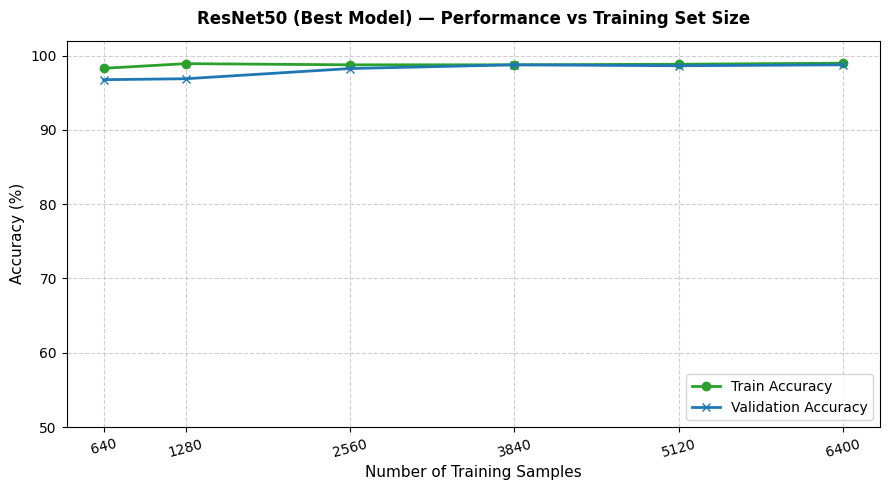

Saved: resnet50_dataset_size_curve.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=final_path, transform=data_transforms)
total_images = len(full_dataset)

train_size = int(0.8 * total_images)
valid_size = int(0.1 * total_images)
test_size  = total_images - train_size - valid_size

torch.manual_seed(42)
train_data, valid_data, test_data = random_split(full_dataset, [train_size, valid_size, test_size])

valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)

fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

curve_train_acc = []
curve_val_acc   = []

BEST_LR      = 0.001
BEST_WD      = 1e-5
BEST_DROPOUT = 0.3
BEST_EPOCHS  = 5

for frac in fractions:
    subset_size = int(frac * len(train_data))
    indices = torch.randperm(len(train_data))[:subset_size]
    train_subset = Subset(train_data, indices)
    train_sub_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

    print(f"\n Training ResNet50 on {subset_size} images ({int(frac*100)}% of training data)...")

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Dropout(p=BEST_DROPOUT),
        nn.Linear(model.fc.in_features, 2)
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=BEST_LR, weight_decay=BEST_WD)

    for epoch in range(BEST_EPOCHS):
        model.train()
        for images, labels in train_sub_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct_train, total_train = 0, 0
    with torch.no_grad():
        for images, labels in train_sub_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_train  += labels.size(0)
            correct_train += (predicted == labels).sum().item()
    train_acc = (correct_train / total_train) * 100

    correct_val, total_val = 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val  += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    val_acc = (correct_val / total_val) * 100

    curve_train_acc.append(train_acc)
    curve_val_acc.append(val_acc)

    print(f"   Subset size: {subset_size} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

x_labels = [int(f * train_size) for f in fractions]

plt.figure(figsize=(9, 5), dpi=100)
plt.plot(x_labels, curve_train_acc, marker='o', label='Train Accuracy', color='#2ca02c', linewidth=2)
plt.plot(x_labels, curve_val_acc,   marker='x', label='Validation Accuracy', color='#1f77b4', linewidth=2)
plt.title('ResNet50 (Best Model) — Performance vs Training Set Size', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Number of Training Samples', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.xticks(x_labels, [str(x) for x in x_labels], rotation=15)
plt.ylim(50, 102)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('resnet50_dataset_size_curve.png', dpi=150)
plt.show()
print("Saved: resnet50_dataset_size_curve.png")

VGG16           | File:  512.21 MB | Total Params: 138.36M
MobileNetV2     | File:    8.73 MB | Total Params: 3.50M
ResNet50        | File:   90.00 MB | Total Params: 25.56M
InceptionV3     | File:   96.15 MB | Total Params: 27.16M

 Model Size & Parameters Summary:


,Architecture,File Size (MB),Total Parameters,Trainable Params
0,VGG16,512.21 MB,138.36M,138.36M
1,MobileNetV2,8.73 MB,3.50M,3.50M
2,ResNet50,90.00 MB,25.56M,25.56M
3,InceptionV3,96.15 MB,27.16M,27.16M


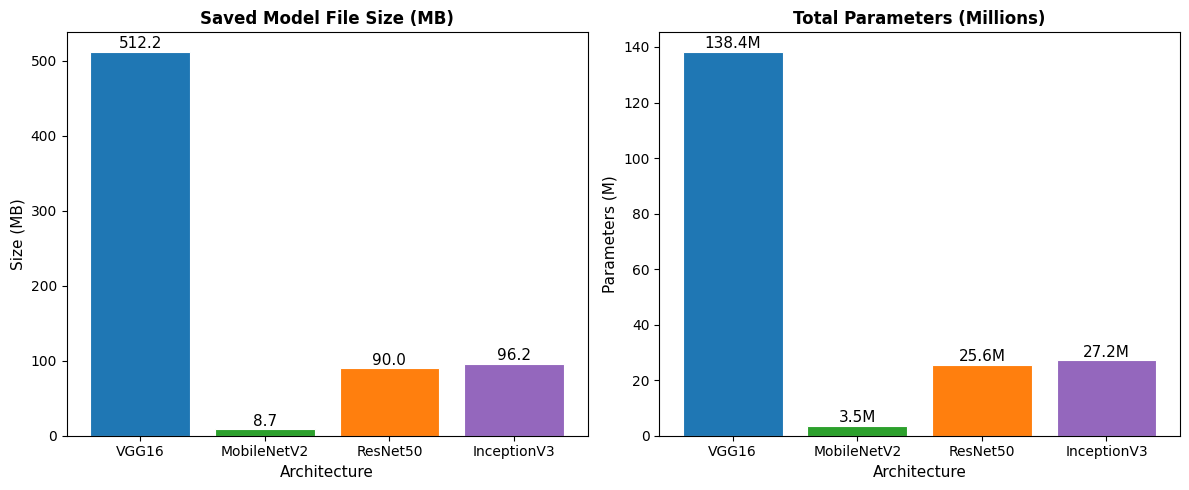

Saved: model_size_comparison.png


In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import pandas as pd
import matplotlib.pyplot as plt

model_specs = {
    'VGG16':       {'path': 'vgg16_best_model.pth',      'params_fn': lambda: models.vgg16()},
    'MobileNetV2': {'path': 'mobilenet_best_model.pth',  'params_fn': lambda: models.mobilenet_v2()},
    'ResNet50':    {'path': 'resnet50_best_model.pth',   'params_fn': lambda: models.resnet50()},
    'InceptionV3': {'path': 'inception_best_model.pth',  'params_fn': lambda: models.inception_v3(init_weights=False)},
}

size_results = []

for name, spec in model_specs.items():
    file_size_mb = 0.0
    if os.path.exists(spec['path']):
        file_size_mb = os.path.getsize(spec['path']) / (1024 * 1024)
    else:
        print(f"Warning: {spec['path']} not found — size will show 0")

    m = spec['params_fn']()
    total_params     = sum(p.numel() for p in m.parameters())
    trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)

    size_results.append({
        'Architecture':        name,
        'File Size (MB)':      f"{file_size_mb:.2f} MB",
        'Total Parameters':    f"{total_params / 1e6:.2f}M",
        'Trainable Params':    f"{trainable_params / 1e6:.2f}M",
    })

    print(f"{name:15s} | File: {file_size_mb:7.2f} MB | Total Params: {total_params/1e6:.2f}M")

df_sizes = pd.DataFrame(size_results)
print("\n Model Size & Parameters Summary:")
display(df_sizes)

arch_names  = [r['Architecture'] for r in size_results]
file_sizes  = [float(r['File Size (MB)'].replace(' MB','')) for r in size_results]
total_parms = [float(r['Total Parameters'].replace('M','')) for r in size_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']

bars1 = ax1.bar(arch_names, file_sizes, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Saved Model File Size (MB)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Size (MB)', fontsize=11)
ax1.set_xlabel('Architecture', fontsize=11)
for bar, val in zip(bars1, file_sizes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='500')

bars2 = ax2.bar(arch_names, total_parms, color=colors, edgecolor='white', linewidth=0.8)
ax2.set_title('Total Parameters (Millions)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Parameters (M)', fontsize=11)
ax2.set_xlabel('Architecture', fontsize=11)
for bar, val in zip(bars2, total_parms):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='500')

plt.tight_layout()
plt.savefig('model_size_comparison.png', dpi=150)
plt.show()
print("Saved: model_size_comparison.png")

In [ ]:
from google.colab import files

files.download('vgg16_best_model.pth')
files.download('mobilenet_best_model.pth')
files.download('resnet50_best_model.pth')
files.download('inception_best_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>